# Concentric Circle Datasets for Mech Interp Research

In [25]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
from pathlib import Path

rng = np.random.default_rng(42)

# Pin CWD to the notebook's own directory so saves always land in the right place
try:
    _nb_dir = Path(__vsc_ipynb_file__).parent  # VS Code
except NameError:
    _nb_dir = Path.cwd()
os.chdir(_nb_dir)

IMG_DIR = Path("images")
DATA_DIR = Path("datasets")
IMG_DIR.mkdir(exist_ok=True)
DATA_DIR.mkdir(exist_ok=True)
print("Saving to:", _nb_dir)

Saving to: /Users/id06/Desktop/PythonProjects/Mech Interp Viz Exploration


## Dataset 1: Two Concentric Circles (inner=red, outer=blue)

In [26]:
def make_ring(n, radius, noise=0.07, rng=rng):
    """Sample n points on a ring. Radial noise is clipped to ±3σ so rings never overlap."""
    angles = rng.uniform(0, 2 * np.pi, n)
    r = np.clip(radius + rng.normal(0, noise, n), radius - 3 * noise, radius + 3 * noise)
    return r * np.cos(angles), r * np.sin(angles)

n_per_class = 500

# Gap between rings: 2.0 - 1.0 = 1.0, noise clip = ±0.21 → clear gap of ~0.58
x_in, y_in = make_ring(n_per_class, radius=1.0)
x_out, y_out = make_ring(n_per_class, radius=2.0)

ds1 = pd.DataFrame({
    "x": np.concatenate([x_in, x_out]),
    "y": np.concatenate([y_in, y_out]),
    "label": ["red"] * n_per_class + ["blue"] * n_per_class,
})

ds1.to_csv(DATA_DIR / "dataset1_two_circles.csv", index=False)
print(ds1["label"].value_counts())

label
red     500
blue    500
Name: count, dtype: int64


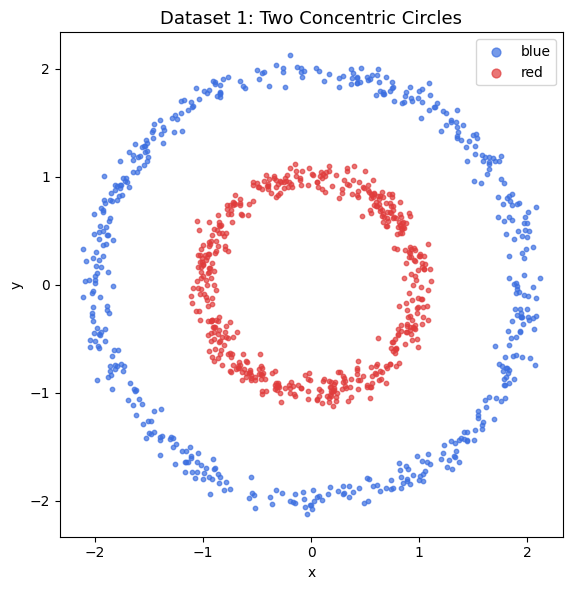

In [27]:
fig, ax = plt.subplots(figsize=(6, 6))
colors = {"red": "#e03c3c", "blue": "#3c6fe0"}
for label, group in ds1.groupby("label"):
    ax.scatter(group["x"], group["y"], c=colors[label], label=label, s=10, alpha=0.7)

ax.set_aspect("equal")
ax.set_title("Dataset 1: Two Concentric Circles", fontsize=13)
ax.legend(markerscale=2)
ax.set_xlabel("x")
ax.set_ylabel("y")
plt.tight_layout()
plt.savefig(IMG_DIR / "dataset1_two_circles.png", dpi=150)
plt.show()

## Dataset 2: Three Concentric Circles (alternating red / blue / red)

In [28]:
ring_specs = [(1.0, "red"), (2.0, "blue"), (3.0, "red")]

frames = []
for radius, label in ring_specs:
    x, y = make_ring(n_per_class, radius=radius)
    frames.append(pd.DataFrame({"x": x, "y": y, "label": label}))

ds2 = pd.concat(frames, ignore_index=True)
ds2.to_csv(DATA_DIR / "dataset2_three_circles.csv", index=False)
print(ds2["label"].value_counts())

label
red     1000
blue     500
Name: count, dtype: int64


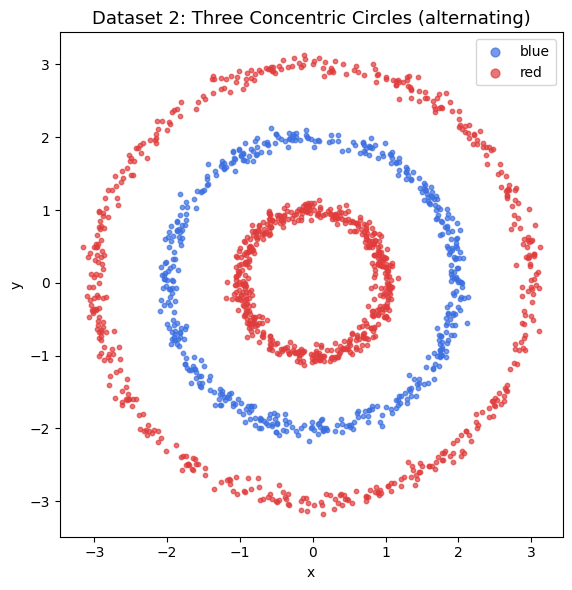

In [29]:
fig, ax = plt.subplots(figsize=(6, 6))
for label, group in ds2.groupby("label"):
    ax.scatter(group["x"], group["y"], c=colors[label], label=label, s=10, alpha=0.7)

ax.set_aspect("equal")
ax.set_title("Dataset 2: Three Concentric Circles (alternating)", fontsize=13)
ax.legend(markerscale=2)
ax.set_xlabel("x")
ax.set_ylabel("y")
plt.tight_layout()
plt.savefig(IMG_DIR / "dataset2_three_circles.png", dpi=150)
plt.show()

## Dataset 3: Four Alternating Vertical Stripes (red / blue / red / blue)

In [53]:
n_stripes = 2000
GAP = 0.1  # dead zone half-width on each side of every boundary

x_all = rng.uniform(-2, 2, n_stripes * 2)  # oversample — gaps will discard some points
y_all = rng.uniform(-1, 1, n_stripes * 2)

# Band boundaries sit at x = -1, 0, 1
# Exclude any point within GAP of a boundary
on_boundary = (np.abs(x_all + 1) < GAP) | (np.abs(x_all) < GAP) | (np.abs(x_all - 1) < GAP)
x_all = x_all[~on_boundary]
y_all = y_all[~on_boundary]

stripe_idx = ((x_all + 2) // 1).astype(int).clip(0, 3)
stripe_labels = np.array(["red", "blue", "red", "blue"])
labels = stripe_labels[stripe_idx]

# Trim to n_stripes total, balanced across 4 bands
ds3 = pd.DataFrame({"x": x_all, "y": y_all, "label": labels})
ds3 = ds3.sample(min(n_stripes, len(ds3)), random_state=42).reset_index(drop=True)
ds3.to_csv(DATA_DIR / "dataset3_stripes.csv", index=False)
print(ds3["label"].value_counts())

label
red     1001
blue     999
Name: count, dtype: int64


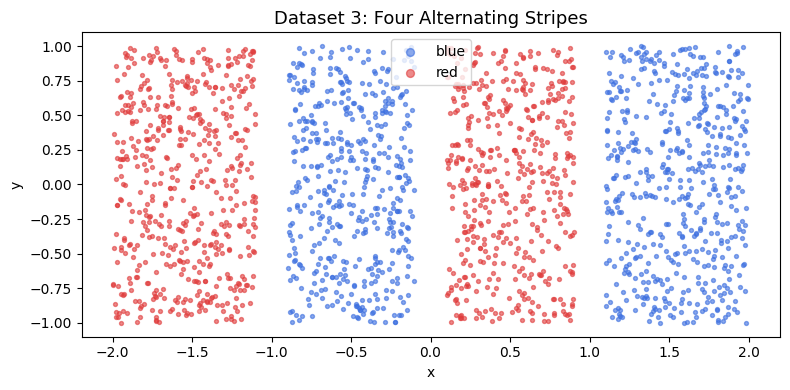

In [54]:
fig, ax = plt.subplots(figsize=(8, 4))
for label, group in ds3.groupby("label"):
    ax.scatter(group["x"], group["y"], c=colors[label], label=label, s=8, alpha=0.6)

ax.set_title("Dataset 3: Four Alternating Stripes", fontsize=13)
ax.legend(markerscale=2)
ax.set_xlabel("x")
ax.set_ylabel("y")
plt.tight_layout()
plt.savefig(IMG_DIR / "dataset3_stripes.png", dpi=150)
plt.show()

## Dataset 4: Sine Wave Decision Boundary (above=blue, below=red)

In [51]:
FREQ = 2        # sin(FREQ * x) → 4 full cycles across [-2π, 2π]
SIN_GAP = 0.5  # dead-zone half-width around the boundary curve

# Oversample then filter out the ambiguous band near the boundary
n_sin_raw = 8000
x_raw = rng.uniform(-np.pi * 2, np.pi * 2, n_sin_raw)
y_raw = rng.uniform(-2.5, 2.5, n_sin_raw)
boundary_raw = 2 * np.sin(FREQ * x_raw)

dist = y_raw - boundary_raw
blue_mask = dist >  SIN_GAP
red_mask  = dist < -SIN_GAP

# Sample 1000 from each class
n_each = 1000
blue_idx = rng.choice(np.where(blue_mask)[0], n_each, replace=False)
red_idx  = rng.choice(np.where(red_mask)[0],  n_each, replace=False)

x_sin = np.concatenate([x_raw[blue_idx], x_raw[red_idx]])
y_sin = np.concatenate([y_raw[blue_idx], y_raw[red_idx]])
labels_sin = ["blue"] * n_each + ["red"] * n_each

ds4 = pd.DataFrame({"x": x_sin, "y": y_sin, "label": labels_sin})
ds4.to_csv(DATA_DIR / "dataset4_sine.csv", index=False)
print(ds4["label"].value_counts())

label
blue    1000
red     1000
Name: count, dtype: int64


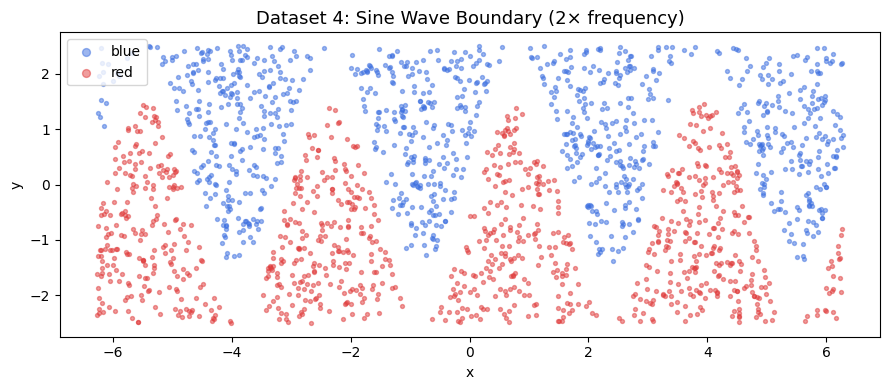

In [52]:
fig, ax = plt.subplots(figsize=(9, 4))
for label, group in ds4.groupby("label"):
    ax.scatter(group["x"], group["y"], c=colors[label], label=label, s=8, alpha=0.5)

x_curve = np.linspace(-np.pi * 2, np.pi * 2, 600)

ax.set_title("Dataset 4: Sine Wave Boundary (2× frequency)", fontsize=13)
ax.legend(markerscale=2)
ax.set_xlabel("x")
ax.set_ylabel("y")
plt.tight_layout()
plt.savefig(IMG_DIR / "dataset4_sine.png", dpi=150)
plt.show()

## Dataset 5: Interlocking Half-Moon Crescents

In [59]:
n_moon = 500
MOON_NOISE = 0.07  # clipped to ±3σ so the two arcs never touch

# Sklearn-style interlocking moons:
#   Red  (outer): upper semicircle centred at origin → (1,0)…(0,1)…(-1,0)
#   Blue (inner): lower semicircle centred at (1, 0), shifted down by 0.4
#                 → (0,-0.4)…(1,-1.4)…(2,-0.4)
# The concave face of each moon opens toward the other, creating the interlock.

angles = rng.uniform(0, np.pi, n_moon)

# Red — upper arc
r_r = np.clip(1.0 + rng.normal(0, MOON_NOISE, n_moon),
              1.0 - 3*MOON_NOISE, 1.0 + 3*MOON_NOISE)
x_r =  r_r * np.cos(angles)
y_r =  r_r * np.sin(angles)

# Blue — mirrored lower arc, offset right by 1 and down by 0.4
angles_b = rng.uniform(0, np.pi, n_moon)
r_b = np.clip(1.0 + rng.normal(0, MOON_NOISE, n_moon),
              1.0 - 3*MOON_NOISE, 1.0 + 3*MOON_NOISE)
x_b = 1.0 - r_b * np.cos(angles_b)
y_b =      -r_b * np.sin(angles_b) + .5

ds5 = pd.DataFrame({
    "x": np.concatenate([x_r, x_b]),
    "y": np.concatenate([y_r, y_b]),
    "label": ["red"] * n_moon + ["blue"] * n_moon,
})
ds5.to_csv(DATA_DIR / "dataset5_moons.csv", index=False)
print(ds5["label"].value_counts())

label
red     500
blue    500
Name: count, dtype: int64


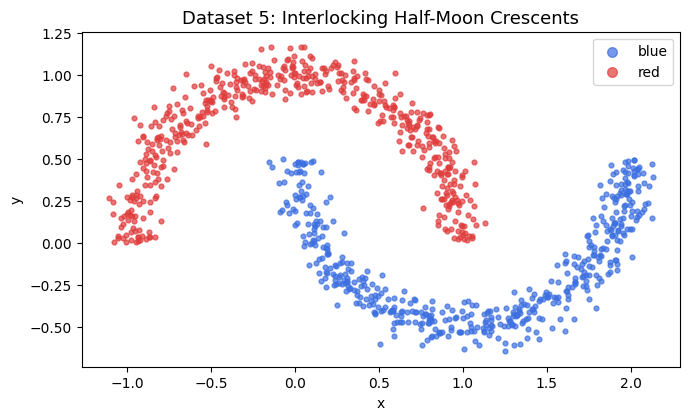

In [60]:
fig, ax = plt.subplots(figsize=(7, 5))
for label, group in ds5.groupby("label"):
    ax.scatter(group["x"], group["y"], c=colors[label], label=label, s=12, alpha=0.7)

ax.set_aspect("equal")
ax.set_title("Dataset 5: Interlocking Half-Moon Crescents", fontsize=13)
ax.legend(markerscale=2)
ax.set_xlabel("x")
ax.set_ylabel("y")
plt.tight_layout()
plt.savefig(IMG_DIR / "dataset5_moons.png", dpi=150)
plt.show()